In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from importlib import reload
import os 
import torch

import matplotlib.pyplot as plt

from datablocks.dbx import DBX, bash_eval

In [3]:
bash_eval("""
export HOME="${HOME}"
        export SEYE="${HOME}/structured-eye"
        export DATALAKE="/mnt/labshare/PANCAN-GIGAPATH"
        export REVISION="gigapath/pancan/v1"
        export CUDA_VISIBLE_DEVICES="0,1,2,3"
""", 
globals=globals())
display(HOME)
display(os.environ['CUDA_VISIBLE_DEVICES'])

'/home/t-9dkarp'

'0,1,2,3'

In [4]:
CPIMGS=DBX('structured_eye.gigapath.IMGS', 'CPIMGS', repo='${SEYE}', revision='${REVISION}').SCOPE(slides=DBX.Path('/mnt/labshare/SLIDES/CPTAC_downloads'), origin='CPTAC', tile_px=256, tile_um=256)
display(CPIMGS)

datablocks.dbx.DBX('structured_eye.gigapath.IMGS', 'CPIMGS', repo='/home/t-9dkarp/structured-eye', revision='gigapath/pancan/v1')

In [5]:
CPIMGS.Databuilder(debug=True).show_dataspace_batches()

 cuInit Failed, error CUDA_ERROR_NO_DEVICE
 cuFile initialization failed
dataspace_batch_scopes: extracting kvhandles for topic project from topicspace datablocks.dataspace.Dataspace('/home/t-9dkarp/.cache/datalake/DBX/structured_eye/gigapath/IMGS/@gigapath|pancan|v1/project')
DEBUG: chase_kvhandles: _dataspace: datablocks.dataspace.Dataspace('/home/t-9dkarp/.cache/datalake/DBX/structured_eye/gigapath/IMGS/@gigapath|pancan|v1/project'): >>>>>>>>>>>>>>>> _kvhandle: ()
DEBUG: chase_kvhandles: pathnames: ['tile_px=256']
DEBUG: chase_kvhandles: processing pathname: 'tile_px=256'
DEBUG: chase_handles: appending ('tile_px', '256') to _kvhandle ()
DEBUG: chase_kvhandles: recursive call into dataspace_ datablocks.dataspace.Dataspace('/home/t-9dkarp/.cache/datalake/DBX/structured_eye/gigapath/IMGS/@gigapath|pancan|v1/project/tile_px=256') with kvhandle_ (('tile_px', '256'),)
DEBUG: chase_kvhandles: _dataspace: datablocks.dataspace.Dataspace('/home/t-9dkarp/.cache/datalake/DBX/structured_eye/gig

[{'tile_px': '256',
  'tile_um': '256',
  'slides': '|mnt|labshare|SLIDES|CPTAC_downloads',
  'origin': 'CPTAC'}]

# GIGAPATH/PANCAN/CPTAC: EMBS

In [4]:
CPIMGS = DBX('structured_eye.gigapath.IMGS', 'CPIMGS', repo=SEYE, revision=REVISION).SCOPE(slides=DBX.Path('/mnt/labshare/SLIDES/CPTAC_downloads'), origin='CPTAC', tile_px=256, tile_um=256)
CPIMGS.build()

 cuInit Failed, error CUDA_ERROR_NO_DEVICE
 cuFile initialization failed


'SUCCESS: True'

In [5]:
CPBAGS = DBX('structured_eye.gigapath.BAGS', 'CPBAGS', repo=SEYE, revision=REVISION).SCOPE(dataset=CPIMGS.READ('dataset'))

In [16]:
CPBAGS.show_build_graph()

In [ ]:
CPEMBS = DBX('structured_eye.gigapath.EMBS', 'CPEMBS', repo=SEYE, revision=REVISION).SCOPE(slides=CPIMGS.READ('slides'), bags=CPBAGS.READ())

In [ ]:
CPEMBS.build()

# GIGAPATH/PANCAN/CPTAC: DISCRETIZATION

In [ ]:
!ls '/mnt/labshare/PANCAN-GIGAPATH/DBX/seye/gigapath/DEVALUATOR/@gigapath|pancan|v1/cdf/features=DBX.seye.gigapath.EMBS@gigapath/pancan/v1#CPEMBS/slide_sources=DBX.seye.gigapath.IMGS@gigapath/pancan/v1#CPIMGS:slide_source_map/n_bins=100/evaluation_fraction=0.8/umap_fraction=0.01'

In [ ]:
CPDEVAL100 = DBX('structured_eye.gigapath.DEVALUATOR', 'CPDEVAL100', repo=SEYE, revision=REVISION).SCOPE(features=CPEMBS.READ(), slide_sources=CPIMGS.READ('slide_source_map'), n_bins=100)

In [ ]:
CPDEVAL100.topics
CPDEVAL100.extent
CPDEVAL100.Databuilder(throw=True, verbose=True).build()

In [ ]:
cdf100 = CPDEVAL100.read('cdf')

In [19]:
cdf100 = torch.load('/mnt/labshare/PANCAN-GIGAPATH/DBX/seye/gigapath/DEVALUATOR/@gigapath|pancan|v1/cdf/features=DBX.seye.gigapath.EMBS@gigapath/pancan/v1#CPEMBS/slide_sources=DBX.seye.gigapath.IMGS@gigapath/pancan/v1#CPIMGS:slide_source_map/n_bins=100/evaluation_fraction=0.8/umap_fraction=0.01/cdf.pt')

In [20]:
cdf100.shape

torch.Size([100, 768])

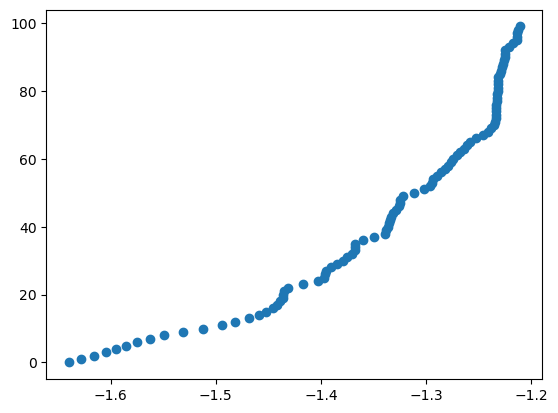

In [33]:
plt.scatter(y=range(100), x=cdf100[:, 0])

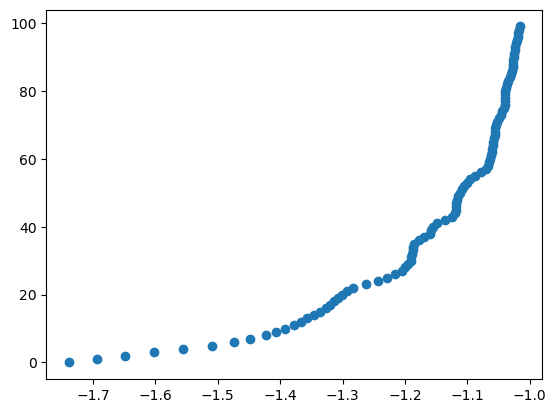

In [34]:
plt.scatter(y=range(100), x=cdf100[:, 1])

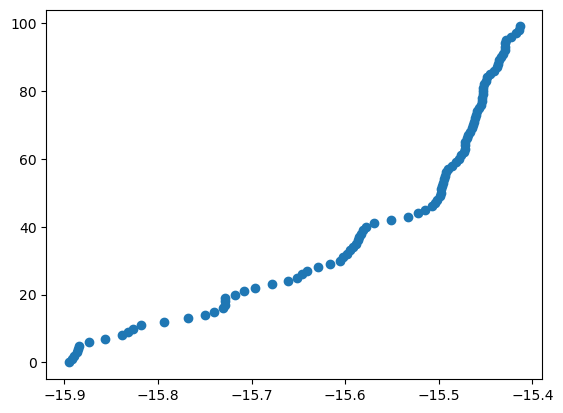

In [35]:
plt.scatter(y=range(100), x=cdf100[:, 100])

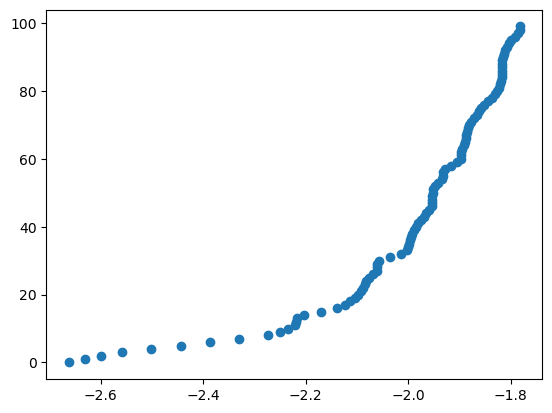

In [37]:
plt.scatter(y=range(100), x=cdf100[:, 200])

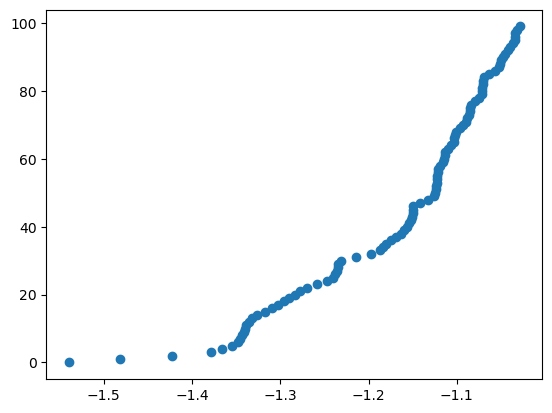

In [38]:
plt.scatter(y=range(100), x=cdf100[:, 300])

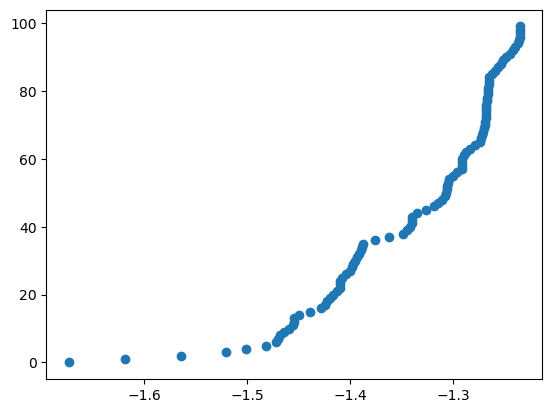

In [36]:
plt.scatter(y=range(100), x=cdf100[:, 500])